In [1]:
#!pip3 install torch torchvision torchaudio
#!pip3 install opencv-python    #cv2
#!pip3 install Pillow   #PIL
#!pip3 install imageio
#!pip3 install tifffile

In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import math
from torch.utils.data import Dataset, DataLoader, random_split
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
from sklearn.metrics import confusion_matrix, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt
from PIL import Image
import imageio  # read gif images
import tifffile # read tiff images
from sklearn.metrics import f1_score

# 資料預處理&擴增

In [ ]:
class Dataset(Dataset):
    def __init__(self, image_dir, gt_dir, transform):
        self.image_dir = image_dir
        self.gt_dir = gt_dir
        self.transform = transform
    
    def __len__(self):
        return len(self.image_dir)
    
    def __getitem__(self, idx):
        # read tif images
        image = Image.open(self.image_dir[idx])
        
        # read gif ground truth
        ground_truth = imageio.mimread(self.gt_dir[idx])[0]
        
        # change grund truth to PIL image
        ground_truth = Image.fromarray(ground_truth)
        
        # change original image and ground truth to grayscale
        ground_truth = ground_truth.convert('L')
        image = image.convert('L')
        
        # Normalize ground truth
        ground_truth = ground_truth.point(lambda x: x/255, mode='1')
        
        # change PIL image to tensor
        to_tensor = transforms.ToTensor()
        image = to_tensor(image)
        ground_truth = to_tensor(ground_truth)
        
        if self.transform:
            # combine the original image and ground truth, 目的是transform隨機擴增會得到相同的擴增效果
            combined = torch.cat((image, ground_truth), dim=0)
            combined = self.transform(combined)
            
            # 將原始影像和ground truth依channel分離並回傳
            image = combined[0:1, :, :]     # first channel for image
            ground_truth = combined[1:2, :, :]  # second channel for label
            
        return image, ground_truth

# 資料擴增(依階段區分)

In [4]:
transform = {
    'train' : transforms.Compose([
        transforms.RandomHorizontalFlip(),      # 隨機水平旋轉
        transforms.RandomVerticalFlip(),        # 隨機垂直旋轉
        transforms.RandomRotation(degrees=15),  # 隨機旋轉(+-15度)
        transforms.RandomAffine(degrees=0, translate=(0.02, 0.02)), # 輕微的平移轉換
    ]),
    'test': transforms.Compose([
        # transforms.ToTensor()
    ])
}

# 設定train和test的路徑

In [5]:
training_base_path = './training'
test_base_path = './test'

# 循序讀取train和test資料夾中的原始影像路徑
train_image_paths = [os.path.join(training_base_path, 'images', img) 
                        for img in os.listdir(os.path.join(training_base_path, 'images')) if img.endswith('.tif')]
test_image_paths = [os.path.join(test_base_path, 'images', img) 
                        for img in os.listdir(os.path.join(test_base_path, 'images')) if img.endswith('.tif')]

# 循序讀取train和test資料夾中的ground truth路徑
train_groundtruth_paths = [os.path.join(training_base_path, '1st_manual', gt) 
                        for gt in os.listdir(os.path.join(training_base_path, '1st_manual')) if gt.endswith('.gif')]
test_groundtruth_paths = [os.path.join(test_base_path, '1st_manual', gt) 
                        for gt in os.listdir(os.path.join(test_base_path, '1st_manual')) if gt.endswith('.gif')]

# 依檔案名稱排序上述路徑，以便影像與其ground truth對應

In [6]:
train_image_paths.sort()
test_image_paths.sort()
train_groundtruth_paths.sort()
test_groundtruth_paths.sort()

# 載入訓練、測試集

In [7]:
train_dataset = Dataset(train_image_paths, train_groundtruth_paths, transform['train'])
test_dataset = Dataset(test_image_paths, test_groundtruth_paths, transform['test'])

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

# 讀取train_dataset的第一筆資料並檢查是否得到相同擴增效果

torch.Size([1, 584, 565])


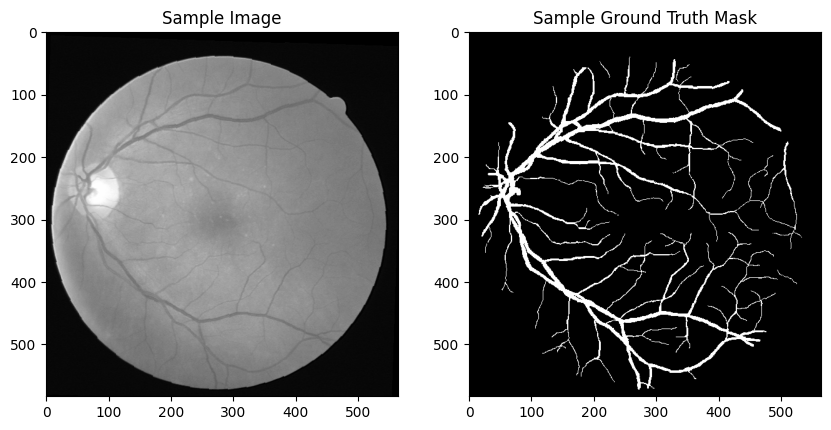

In [8]:
sample_image, sample_mask = train_dataset[0]
print(sample_image.shape)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(sample_image.squeeze(), cmap='gray')
plt.title('Sample Image')
plt.subplot(1, 2, 2)
plt.imshow(sample_mask.squeeze(), cmap='gray')
plt.title('Sample Ground Truth Mask')
plt.show()

# Model

In [10]:
class DoubleConv(nn.Module):
    """(convolution => [BN] => ReLU) * 2"""

    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if not mid_channels:
            mid_channels = out_channels
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class Down(nn.Module):
    """Downscaling with maxpool then double conv"""

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)

class Up(nn.Module):
    """Upscaling then double conv"""

    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()

        # if bilinear, use the normal convolutions to reduce the number of channels
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels, in_channels // 2)
        else:
            self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        # input is CHW
        diffY = torch.tensor([x2.size()[2] - x1.size()[2]])
        diffX = torch.tensor([x2.size()[3] - x1.size()[3]])

        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, n_channels, n_classes, bilinear=True):
        super(UNet, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        self.inc = (DoubleConv(n_channels, 64))
        self.down1 = (Down(64, 128))
        self.down2 = (Down(128, 256))
        self.down3 = (Down(256, 512))
        factor = 2 if bilinear else 1
        self.down4 = (Down(512, 1024 // factor))
        self.up1 = (Up(1024, 512 // factor, bilinear))
        self.up2 = (Up(512, 256 // factor, bilinear))
        self.up3 = (Up(256, 128 // factor, bilinear))
        self.up4 = (Up(128, 64, bilinear))
        self.outc = (OutConv(64, n_classes))

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        return logits

    def use_checkpointing(self):
        self.inc = torch.utils.checkpoint(self.inc)
        self.down1 = torch.utils.checkpoint(self.down1)
        self.down2 = torch.utils.checkpoint(self.down2)
        self.down3 = torch.utils.checkpoint(self.down3)
        self.down4 = torch.utils.checkpoint(self.down4)
        self.up1 = torch.utils.checkpoint(self.up1)
        self.up2 = torch.utils.checkpoint(self.up2)
        self.up3 = torch.utils.checkpoint(self.up3)
        self.up4 = torch.utils.checkpoint(self.up4)
        self.outc = torch.utils.checkpoint(self.outc)

In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# 灰階輸入輸出維度皆為1
model = UNet(n_channels=1, n_classes=1).to(device)

# Loss (DiceLoss + BCEWithLogitsLoss)

In [12]:
class DiceLoss(nn.Module):
    def forward(self, inputs, targets, smooth=1e-8):
        inputs = torch.sigmoid(inputs)
        inputs = inputs.view(-1)
        targets = targets.view(-1)
        intersection = (inputs * targets).sum()
        dice_coeff = (2. * intersection + smooth) / (inputs.sum() + targets.sum() + smooth)
        return 1 - dice_coeff
    
class CombinedLoss(nn.Module):
    def __init__(self, alpha, beta):
        super(CombinedLoss, self).__init__()
        self.alpha = alpha
        self.beta = beta
        self.dice_loss = DiceLoss()
        self.BCE_loss = nn.BCEWithLogitsLoss()
        
    def forward(self, inputs, targets):
        dice = self.dice_loss(inputs, targets)
        BCE = self.BCE_loss(inputs, targets)
        return self.alpha * dice + self.beta * BCE
    
criterion = CombinedLoss(alpha=0.4, beta=0.6)
optimizer = optim.RMSprop(model.parameters(), lr=1e-4, weight_decay=1e-8, momentum=0.9)

# IoU

In [22]:
def iou_score(output, target):
    intersection = torch.logical_and(output, target).sum()
    union = torch.logical_or(output, target).sum()
    iou = intersection / union if union>0 else 0.0
    return iou

# Train

Epoch [1/200], Loss: 0.529734, IoU: 0.3382
Epoch [50/200], Loss: 0.184178, IoU: 0.6259
Epoch [100/200], Loss: 0.165306, IoU: 0.6512
Epoch [150/200], Loss: 0.156043, IoU: 0.6648
Epoch [200/200], Loss: 0.149978, IoU: 0.6741


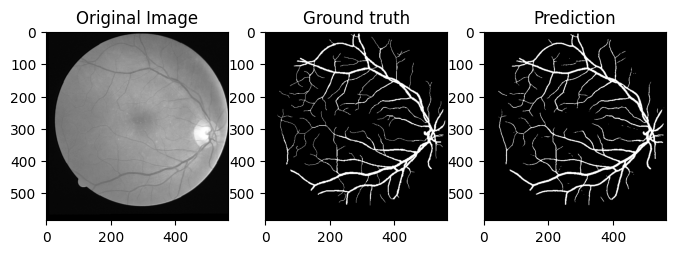

In [14]:
num_epochs = 200
total_loss = 0
total_iou = 0
count = 0

for epoch in range(num_epochs):
    model.train()
    for batch in train_loader:
        images, masks = batch
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        total_loss += loss.item()
        iou = iou_score(outputs, masks)
        total_iou += iou.item()
        loss.backward()
        optimizer.step()
        count += 1

    avg_loss = total_loss / count
    avg_iou = total_iou / count
    if (epoch==0 or (epoch+1)%50==0):
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.6f}, IoU: {avg_iou:.4f}')

    # 顯示結果(最後一個epoch)
    if epoch == num_epochs-1:
        images, masks = next(iter(train_loader))
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)
        outputs = torch.sigmoid(outputs)
        pred = (outputs > 0.5)*255
        pred = np.array(pred.data.cpu())

        fig, ax = plt.subplots(nrows=images.size(0), ncols=3, figsize=(8, images.size(0)*3))
        if images.size(0) == 1:
            ax = [ax]
        for i in range(images.size(0)):
            ax[i][0].imshow(images[i].cpu().squeeze(), cmap='gray')   # 原圖
            ax[i][1].imshow(masks[i].cpu().squeeze(), cmap='gray')    # ground truth
            ax[i][2].imshow(pred[i].squeeze(), cmap='gray')     # 預測輸出
            ax[0][0].set_title('Original Image')
            ax[0][1].set_title('Ground truth')
            ax[0][2].set_title('Prediction')
        plt.show()

# 測試模型

In [23]:
def evaluate_model(loader, model,  device='cpu'):
    model.eval()
    count = 0
    total_iou = 0
    all_preds = []
    all_trues = []
    all_probs = []
    with torch.no_grad():
        for batch in loader:
            x, y = batch
            x = x.to(device='cpu', dtype=torch.float32)
            y = y.to(device='cpu', dtype=torch.float32)
            probs = torch.sigmoid(model(x))
            preds = (probs > 0.5).float()
            iou = iou_score(preds, y)
            total_iou += iou.item()

            count += 1
            all_preds.extend(preds.view(-1).cpu().numpy())
            all_trues.extend(y.view(-1).cpu().numpy())
            all_probs.extend(probs.view(-1).cpu().numpy())

    cm = confusion_matrix(all_trues, all_preds)
    TP = cm[1, 1]
    FP = cm[0, 1]
    TN = cm[0, 0]
    FN = cm[1, 0]

    accuracy = (TP + TN)/(TP +  FP + TN + FN)
    recall = TP/(TP + FN)
    precision = TP/(TP + FP)
    specificity = TN/(TN + FP)
    F1 = 2*(precision*recall)/(precision + recall)
    AUC = roc_auc_score(all_trues, all_probs)
    miou = total_iou / count
    return accuracy, recall, precision, specificity, F1, AUC, miou

accuracy, recall, precision, specificity, F1, AUC, miou = evaluate_model(test_loader, model.to('cpu'), device)

print(f'Accuracy: {accuracy:.4f}\nRecall: {recall:.4f}\nPrecision: {precision:.4f}\nSpecificity: {specificity:.4f}\nF1: {F1:.4f}\nAUC: {AUC:.4f}\nmIoU: {miou:.4f}')

Accuracy: 0.9677
Recall: 0.8346
Precision: 0.8039
Specificity: 0.9805
F1: 0.8190
AUC: 0.9847
mIoU: 0.6932


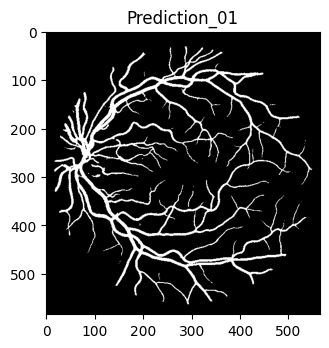

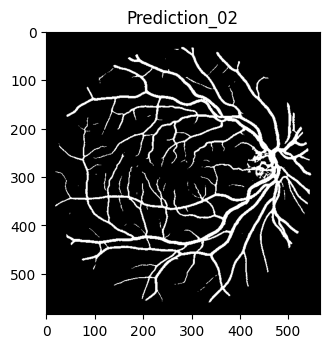

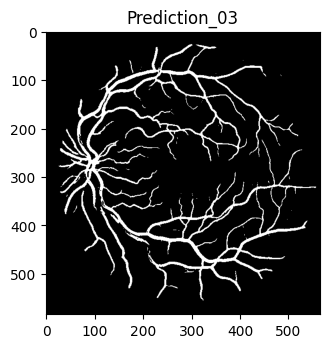

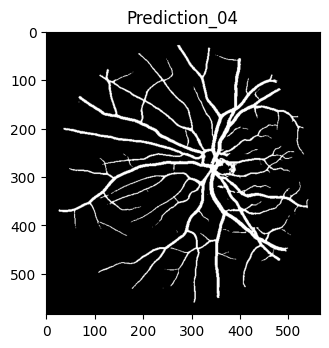

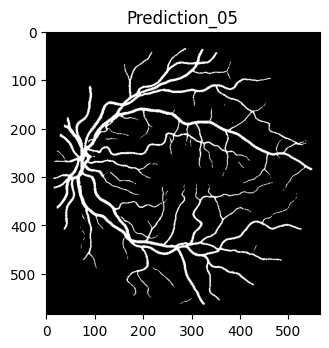

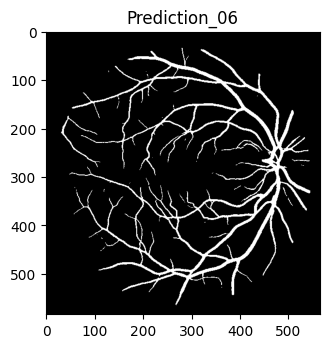

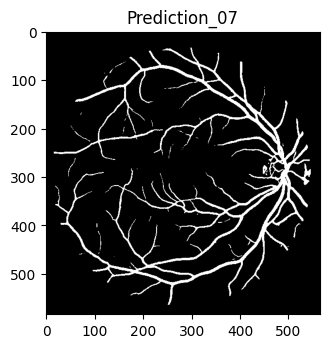

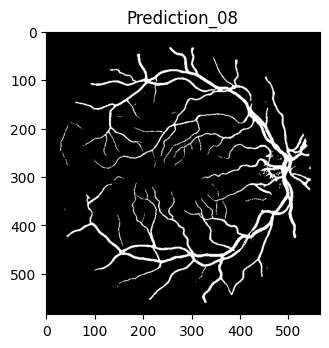

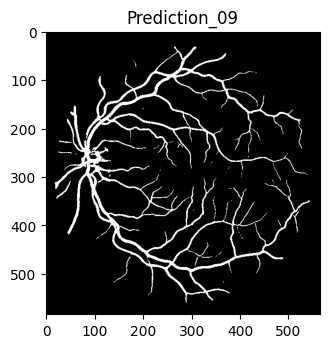

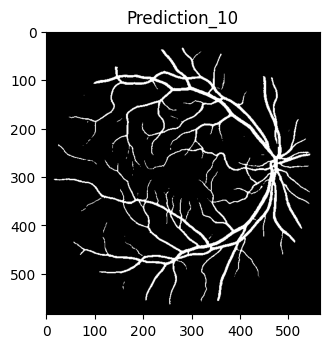

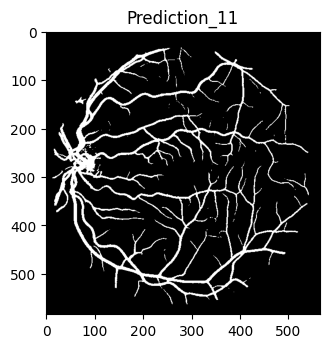

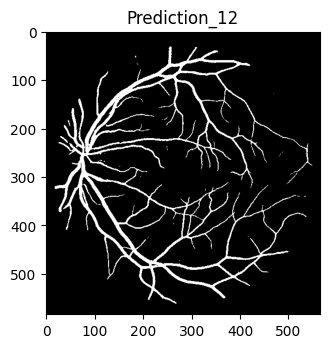

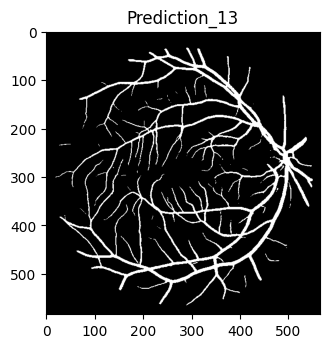

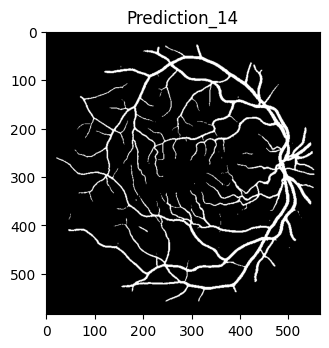

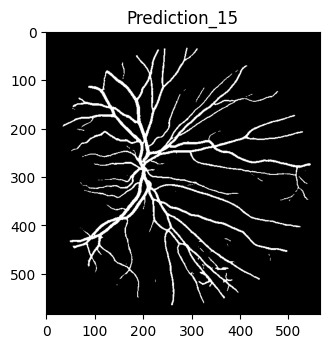

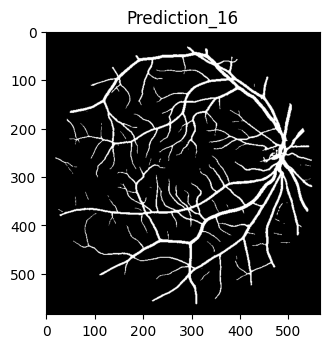

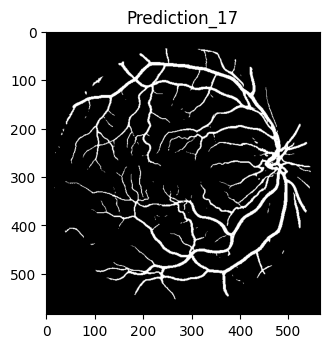

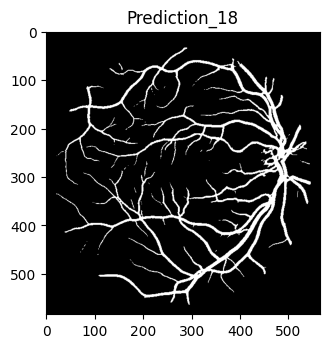

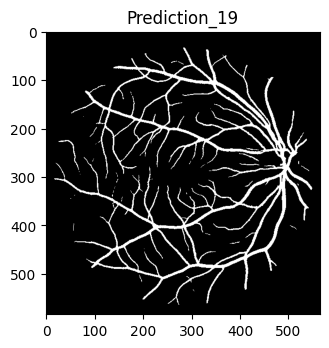

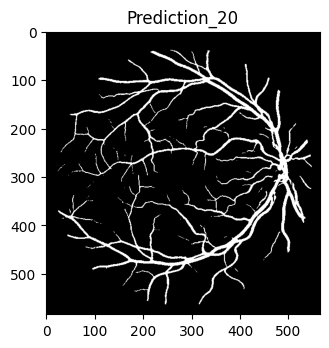

image_metrics.csv saved
    Image       IoU  F1 Score
0       1  0.703645  0.826046
1       2  0.721210  0.838027
2       3  0.645747  0.784746
3       4  0.708390  0.829307
4       5  0.695963  0.820729
5       6  0.686279  0.813957
6       7  0.686866  0.814369
7       8  0.666342  0.799766
8       9  0.674145  0.805360
9      10  0.683780  0.812196
10     11  0.661786  0.796476
11     12  0.716612  0.834914
12     13  0.707959  0.829012
13     14  0.710901  0.831025
14     15  0.678148  0.808210
15     16  0.722989  0.839226
16     17  0.679091  0.808880
17     18  0.681835  0.810823
18     19  0.748292  0.856027
19     20  0.683387  0.811919
mIoU: 0.6932


In [26]:
model.eval()
folder = './prediction'
if not os.path.exists(folder):
    os.makedirs(folder)

results = []
total_iou = 0
count = 0
for i, (x, y) in enumerate(test_loader):
    x = x.to(device='cpu', dtype=torch.float32)
    y = y.to(device='cpu', dtype=torch.float32)
    with torch.no_grad():
        model = model.to('cpu')
        probs = torch.sigmoid(model(x))
        preds = (probs > 0.5).to(torch.uint8)*255
        iou = iou_score(preds, y)
        total_iou += iou
        f1 = f1_score(y.view(-1).cpu().numpy(), (probs > 0.5).float().view(-1).cpu().numpy())
        results.append({
            'Image': i+1,
            'IoU': iou.item(),
            'F1 Score': f1
        })
        count += 1

        # 顯示結果
        plt.figure(figsize=(12,4))
        plt.subplot(1, 3, 1)
        plt.imshow(preds.squeeze(), cmap='gray')
        plt.title(f'Prediction_{i+1:02}')
        plt.show()

        torchvision.utils.save_image(preds.float()/255, os.path.join(folder, f"{i+1:02}_prediction.png"))

results_df = pd.DataFrame(results)
results_df.to_csv("image_metrics.csv", index=False)

print("image_metrics.csv saved")
print(results_df)

mIoU = total_iou / count
print(f'mIoU: {mIoU:.4f}')